VII. Regularization and Shrinkage (5 points)

What you should do:

 Compare at least two models (e.g., simple vs regularized)

 Explain how shrinkage affects performance

Connection to class: Bias–variance + Regularization

In [38]:
import pandas
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

In [39]:
data = pandas.read_csv("../data/finaldiabetes.csv")

target = 'time_in_hospital'

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target]

y = data[target].values
X = data[feature_cols].values

In [40]:
X_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
x_test = scaler.transform(x_test)

In [41]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred = model.predict(x_test)

In [43]:
beta_mle = model.coef_
beta_mle

array([-0.04854003,  0.33788432,  0.00201109,  0.58587324,  0.1116133 ,
        1.0942758 , -0.10238831, -0.07052977,  0.11411712,  0.24171062,
        0.04919393])

In [44]:
mse_mle = mean_squared_error(y_test, y_pred)
mse_mle

6.436660501880184

In [ ]:
p = X_train.shape[1]
n = X_train.shape[0]
assert p >= 3, f"James-Stein requires p >= 3, got p={p}"

y_pred_train = model.predict(X_train)
residuals    = y_train - y_pred_train
sigma2       = np.sum(residuals ** 2) / (n - p - 1)

y_hat_train = X_train @ beta_mle               
norm_sq     = np.sum(y_hat_train ** 2)         
c = float(np.clip(1 - (p - 2) * sigma2 / norm_sq, 0.0, 1.0))

y_hat_test = x_test @ beta_mle
y_pred_js  = c * y_hat_test + model.intercept_
mse_js     = mean_squared_error(y_test, y_pred_js)

print(f"JS MSE:          {mse_js:.4f}")
print(f"Shrinkage c:     {c:.4f}  (1=none, 0=full)")
print(f"MSE improvement: {mse_mle - mse_js:.4f}")

JS MSE:          6.4367
Shrinkage c:     0.9997  (1=none, 0=full)
MSE improvement: -0.0000


In [46]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 100)  # search from 0.001 to 1000
ridge  = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

beta_ridge   = ridge.coef_
y_pred_ridge = ridge.predict(x_test)
mse_ridge    = mean_squared_error(y_test, y_pred_ridge)

print(f"Ridge MSE:    {mse_ridge:.4f}")
print(f"Best alpha:   {ridge.alpha_:.4f}")

Ridge MSE:    6.4367
Best alpha:   61.3591


In [47]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 100)  # search from 0.001 to 1000
ridge  = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

beta_ridge   = ridge.coef_
y_pred_ridge = ridge.predict(x_test)
mse_ridge    = mean_squared_error(y_test, y_pred_ridge)

print(f"Ridge MSE:    {mse_ridge:.4f}")
print(f"Best alpha:   {ridge.alpha_:.4f}")

Ridge MSE:    6.4367
Best alpha:   61.3591


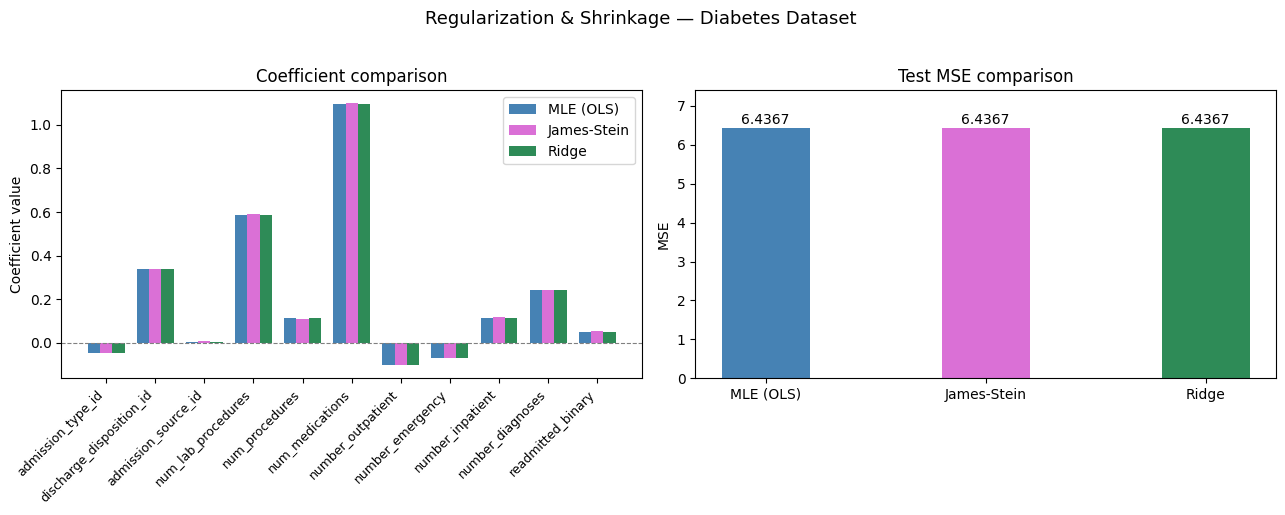

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
x_pos = np.arange(p)
w = 0.25  
axes[0].bar(x_pos - w, beta_mle,   w, label="MLE (OLS)",    color="steelblue")
axes[0].bar(x_pos,     beta_js,    w, label="James-Stein",  color="orchid")
axes[0].bar(x_pos + w, beta_ridge, w, label="Ridge",        color="seagreen")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(feature_cols, rotation=45, ha="right", fontsize=9)
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[0].set_title("Coefficient comparison")
axes[0].set_ylabel("Coefficient value")
axes[0].legend()

bars = axes[1].bar(
    ["MLE (OLS)", "James-Stein", "Ridge"],
    [mse_mle, mse_js, mse_ridge],
    color=["steelblue", "orchid", "seagreen"],
    width=0.4
)
for bar, val in zip(bars, [mse_mle, mse_js, mse_ridge]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=10
    )
axes[1].set_title("Test MSE comparison")
axes[1].set_ylabel("MSE")
axes[1].set_ylim(0, max(mse_mle, mse_js, mse_ridge) * 1.15)
plt.suptitle("Regularization & Shrinkage — Diabetes Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Signal-to-noise ratio: {norm_sq / ((p-2) * sigma2):.1f}x")

Signal-to-noise ratio: 3542.9x
(JS only helps when this ratio is near 1)


Shrinkage through the james stein estimator shows a marginal effect on performance. This is likely due to the large size of the dataset. Since there is so much data present the OLS model is able to perform well against unseen data. As a result, regularization has little to adjust in terms of optimizing the MSE, the OLS in this instance was already very effective. Ridge regression was added in an attempt to break parity. Ridge regularization shows an equally minimal decrease in MSE.